## Downloading data

In [1]:
# import kagglehub

# path = kagglehub.dataset_download("wenruliu/adult-income-dataset")

# print("Path to dataset files:", path)

## Preprocessing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
)
# load dataset downloaded from kaggle
df = pd.read_csv("data/adult.csv")

In [3]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [5]:
df["workclass"].value_counts()

Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: workclass, dtype: int64

In [6]:
# clean missing
df = df.replace("?", np.nan).dropna()

"?" is not a realistic value, if we keep them, the model will get confused.

## Define target col

In [7]:
TARGET_COL = "income"

In [8]:
# Convert income labels to binary 0 or 1
y = df[TARGET_COL].astype(str).str.contains(">50K").astype(int)

X = df.drop(columns=[TARGET_COL])

Define target column and seperate it with other input columns. We want to look at the person's info to predict if their income is either >50K or <=50K So we clean data and turn the target col into binary 0 and 1. A numeric prediction results is cleaner for metrics and consistency.

## Test/Train split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 80, 20 percent ratio
    random_state=42,
    stratify=y
)

Test and training data spliting into 70/30 ratio. Essential in ML model training. Test data must be seperate. 

## Preprocessing

In [10]:
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, numeric_cols),
        ("cat", categorical_preprocess, categorical_cols),
    ],
    remainder="drop"
)

Different kind of input columns needs different handle methods. One is numeric kind other is like words. For the missing values in the columns, numeric ones we just fill in the median of the column, what could have been done alternatively is to use average value or KNN imputation, and for missing values in the words columns we fill in the most commen value that appeared in the dataset. One hot encoder, why is it necessary, Decision trees need numbers, they can't split based on raw string values. The handle_unknow parameter is situatied when the test data has a new column that is never encountered in the training data, it will just ignore it. 

## Model pipeline

In [11]:
clf = DecisionTreeClassifier(random_state=42)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", clf)
])

to call the preprocess and train the model.
Decision Tree is like a game of 20 questions,
It repeatedly asks:

“Is age > 37.5?”

“Is education = Bachelors?”

“Is hours-per-week > 40?”

Each question splits people into two groups.
At the end (leaf), it outputs the majority class.

# How does it choose the “best” question?

It tries to make the groups as “pure” as possible.

That’s what Gini and Entropy measure: impurity.

# Gini impurity

If a node has 50/50 classes → high impurity

If a node is almost all one class → low impurity

The tree chooses the split that reduces impurity the most.

## Hyperparameter tuning (GridSearchCV)

In [12]:
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 8, 10, 12, None],
    "model__min_samples_split": [2, 10, 50, 200],
    "model__min_samples_leaf": [1, 5, 20, 50],
    "model__ccp_alpha": [0.0, 0.0001, 0.001],  # cost-complexity pruning
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1",        # Adult income is imbalanced-ish; F1 is usually better than accuracy
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['age',
                                                                          'fnlwgt',
                                                                          'educational-num',
                                                                          'capital-gain',
                                                                          'capital-loss',
                                                                          'hours-per-week']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(stra...
                                                                          'occupation',
                                                                          'relationship',
                                                                          'race',
                                                                          'gender',
                                                                          'native-country'])])),
                                       ('model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__ccp_alpha': [0.0, 0.0001, 0.001],
                         'model__criterion': ['gini', 'entropy'],
                         'model__max_depth': [3, 5, 8, 10, 12, None],
                         'model__min_samples_leaf': [1, 5, 20, 50],
                         'model__min_samples_split': [2, 10, 50, 200]},
             scoring='f1', verbose=1)

Hyperparameter tuning with GridSearchCV
Tuning often improves performance and helps with avoiding overfitting problem. Alternatively RandomSearch or Bayesian optimization.

max_depth

“How many questions max?”

small depth = simple tree (may underfit)

big depth = complex tree (may overfit)

min_samples_split

“Don’t split a group unless it has at least this many people”
Helps stop silly splits on tiny groups.

min_samples_leaf

“Each final group must have at least this many people”
Again helps stop overfitting.

criterion (gini vs entropy)

Two ways to measure “messiness” in a node.

ccp_alpha

Pruning strength (cost-complexity pruning):
“Cut off small branches that don’t help much.”

Cross validation is also used, why?
cv=5 means:
Split training data into 5 parts:

train on 4 parts

validate on 1 part
Repeat so each part gets to be validation once.

instead of validating it once, we validate it 5 times so that it should be more fair.

We could increas the number of K for cv but it could be much slower.

In [13]:
print("\nBest parameters:")
print(grid.best_params_)
print("\nBest CV F1:")
print(grid.best_score_)


Best parameters:
{'model__ccp_alpha': 0.0001, 'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 200}

Best CV F1:
0.6813624330858288


we choose F1 score over accuracy, in general sence adult income is not really balanced (more <=50K than >50K). So if a model just predict that everyone has a <50K income, the accuracy of that model won't be very low neither. 
F1-score focuses on the positive class quality

F1 balances:

Precision: “When I predict >50K, how often am I correct?”

Recall: “Out of real >50K people, how many did I find?”

In [14]:
best_model = grid.best_estimator_

## Evaluation on test set

In [15]:
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nTEST METRICS")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

# Some ROC/AUC metrics require probabilities
# Decision trees support predict_proba by default
y_proba = best_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC  : {auc:.4f}")


TEST METRICS
Accuracy: 0.8551
F1-score : 0.6803

Classification report:
              precision    recall  f1-score   support

           0     0.8821    0.9318    0.9063      6803
           1     0.7504    0.6222    0.6803      2242

    accuracy                         0.8551      9045
   macro avg     0.8163    0.7770    0.7933      9045
weighted avg     0.8495    0.8551    0.8503      9045

ROC-AUC  : 0.9018


ROC-AUC (Receiver Operating Characteristic Area Under the Curve), Instead of just saying “yes/no”, the model also says: “I’m 83% sure this person is >50K.”
ROC-AUC measures how well it ranks positives above negatives overall.

Why is it useful? ==> ROC-AUC is threshold-independent. Good if we later might choose different thresholds.

ROC Curve: Plots the True Positive Rate against the False Positive Rate at various thresholds.

AUC Interpretation:

1.0: Perfect model.

0.5: Random guessing (diagonal line).

< 0.5: Generally indicates poor model performance or inverted labels.

## Plots: Confusion matrix + ROC curve

<Figure size 640x480 with 0 Axes>

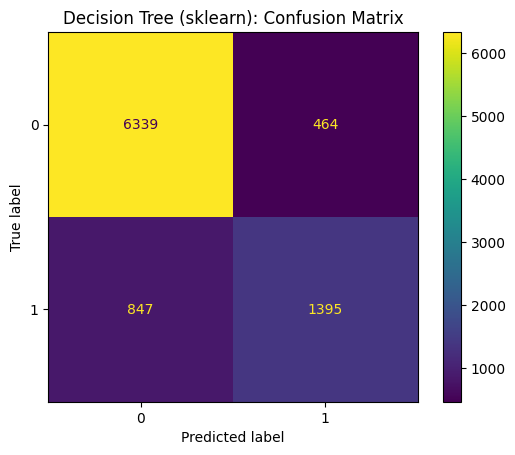

<Figure size 640x480 with 0 Axes>

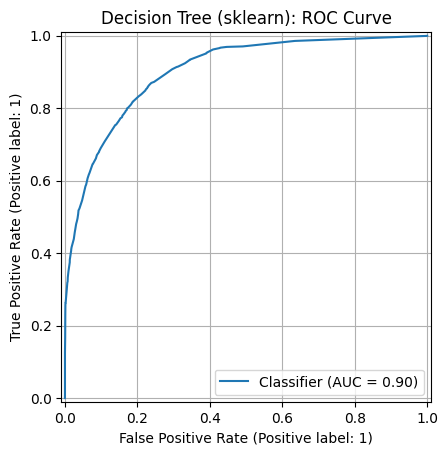

In [16]:
plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, values_format="d")
plt.title("Decision Tree (sklearn): Confusion Matrix")
plt.grid(False)
plt.savefig("sk_cm.png", bbox_inches="tight", dpi=200)
plt.show()

plt.figure()
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Decision Tree (sklearn): ROC Curve")
plt.grid(True)
plt.savefig("sk_roc.png", bbox_inches="tight", dpi=200)
plt.show()


Confusion matrix plot.

A 2×2 table:

True Positive: predicted >50K and correct

False Positive: predicted >50K but wrong

True Negative: predicted <=50K and correct

False Negative: predicted <=50K but wrong

It shows in general what kind of mistakes the model makes.

ROC(Receiver Operating Characteristic) curve plot

Shows tradeoff:

True Positive Rate vs False Positive Rate as threshold changes.

If we change how strict the model is, this shows how sensitivity and false alarms change.

## Plot: Feature importances (top 20)

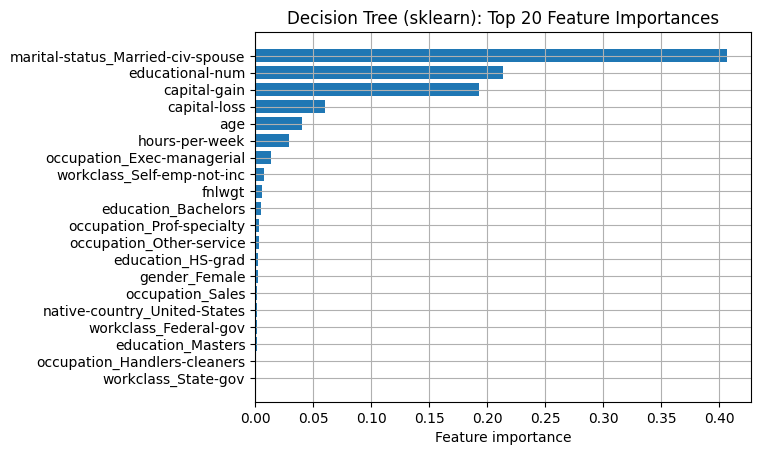

In [17]:
pre = best_model.named_steps["preprocess"]
ohe = pre.named_transformers_["cat"].named_steps["onehot"]

# Numeric names + one-hot names
num_names = numeric_cols
cat_names = ohe.get_feature_names_out(categorical_cols).tolist()
feature_names = num_names + cat_names

tree = best_model.named_steps["model"]
importances = tree.feature_importances_

# Safety: in rare cases, lengths can differ due to pipeline quirks; guard it
m = min(len(feature_names), len(importances))
feature_names = feature_names[:m]
importances = importances[:m]

top_k = 20
idx = np.argsort(importances)[-top_k:]

plt.figure()
plt.barh(np.array(feature_names)[idx], importances[idx])
plt.xlabel("Feature importance")
plt.title(f"Decision Tree (sklearn): Top {top_k} Feature Importances")
plt.grid(True)
plt.savefig("sk_feature_importance.png", bbox_inches="tight", dpi=200)
plt.show()

Decision trees can estimate which features were most useful for splitting.

It tells us which clues the tree used most when making decisions. Great for interpretation and report discussion.

## Plot: Learning curve (diagnose under/overfitting)

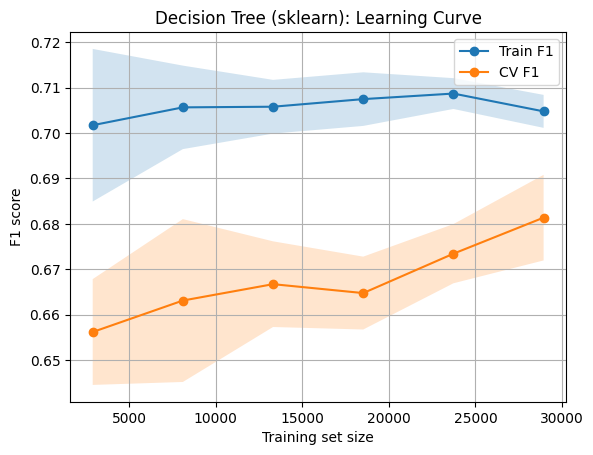

In [18]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train, y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6),
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o", label="Train F1")
plt.plot(train_sizes, val_mean, marker="o", label="CV F1")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.xlabel("Training set size")
plt.ylabel("F1 score")
plt.title("Decision Tree (sklearn): Learning Curve")
plt.grid(True)
plt.legend()
plt.savefig("sk_learning_curve.png", bbox_inches="tight", dpi=200)
plt.show()

two lines of Training F1 score and CV F1 score, so basiclly we check if the model performs much better in Training set than Validation set, the answer here is no. Just 0.05 better ingeneral. So it's not overfitting. 

## Plot: CV results heatmap-like (simple 1D plot)

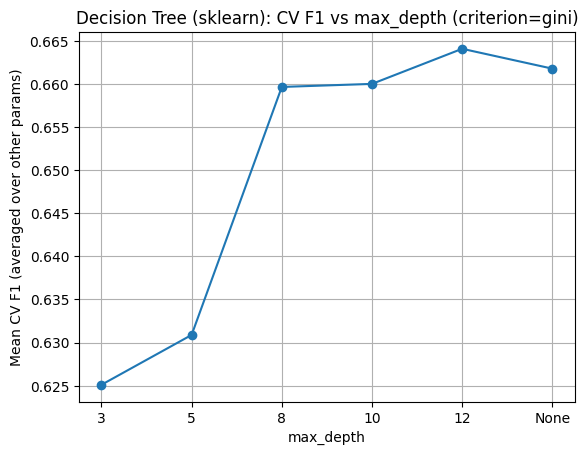

In [19]:
cv_results = pd.DataFrame(grid.cv_results_)

# Pick the best criterion to keep it readable
best_criterion = grid.best_params_["model__criterion"]
subset = cv_results[cv_results["param_model__criterion"] == best_criterion].copy()

# Convert max_depth None to string for plotting
subset["depth_str"] = subset["param_model__max_depth"].astype(str)

# Aggregate mean F1 by depth (averaging over other params)
agg = subset.groupby("depth_str")["mean_test_score"].mean().reset_index()
# Keep a sensible order
order = ["3", "5", "8", "10", "12", "None"]
agg["depth_str"] = pd.Categorical(agg["depth_str"], categories=order, ordered=True)
agg = agg.sort_values("depth_str")

plt.figure()
plt.plot(agg["depth_str"].astype(str), agg["mean_test_score"], marker="o")
plt.xlabel("max_depth")
plt.ylabel("Mean CV F1 (averaged over other params)")
plt.title(f"Decision Tree (sklearn): CV F1 vs max_depth (criterion={best_criterion})")
plt.grid(True)
plt.savefig("sk_cv_f1_vs_depth.png", bbox_inches="tight", dpi=200)
plt.show()

We summarize GridSearch results to see how depth affects performance on average. It's like “How many questions should the tree be allowed to ask?” 